In [1]:
# import required libraries 
import pandas as pd
import math
import random
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl
from openpyxl.styles import PatternFill
import squarify
import stemgraphic
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats as stats
import mlxtend
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth

# **About the Dataset**

Drugs, Side Effects and Medical Condition Dataset:

https://www.kaggle.com/datasets/jithinanievarghese/drugs-side-effects-and-medical-condition

Data contains details of various drugs (used for conditions like Acne, Cancer, Heart Disease, etc. ) and their side effects

The dataset contains 17 columns

- **drug_name**: Name of the drug
- **medical_condition**: The medical condition for which the drug is used
- **side_effects**: A tuple of cut-short explanations of the side-effects of using the specific drug for the specific medical condition
- **generic_name**: Common name of the drug
- **drug_classes**: The class to which the drug belongs to
- **brand_names**: Brand names in which the drugs are sold or are available
- **activity**: A measure to check the site-visitor activity relative to other medications list
- **rx_otc**: OTC - Medication can be purchased without a prescription, Rx - Prescription Needed, Rx/OTC -prescription or over-the-counter
- **pregnancy_category**: A = Adequate and well-controlled studies have failed to demonstrate a risk to the fetus in the first trimester of pregnancy (and there is no evidence of risk in later trimesters), B = Animal reproduction studies have failed to demonstrate a risk to the fetus and there are no adequate and well-controlled studies in pregnant women, C = Animal reproduction studies have shown an adverse effect on the fetus and there are no adequate and well-controlled studies in humans, but potential benefits may warrant use in pregnant women despite potential risks, D = There is positive evidence of human fetal risk based on adverse reaction data from investigational or marketing experience or studies in humans, but potential benefits may warrant use in pregnant women despite potential risks, X = Studies in animals or humans have demonstrated fetal abnormalities and/or there is positive evidence of human fetal risk based on adverse reaction data from investigational or marketing experience, and the risks involved in use in pregnant women clearly outweigh potential benefits, N = FDA has not classified the drug.
- **csa**: Controlled Substances Act(CSA) Schedule. M - Multiple Schedules, U - Schedule is unknown, N - Is not related to csa
- **alcohol**: X - interacts with alcohol
- **related_drugs**: drugs related to the drug in discussion
- **medical_condition_description**: description of the condition for which the drug can be used
- **rating**: effectiveness of the drug (user-ratings)
- **no_of_reviews**: No of reviews
- **drug_link**: a link to access more information about the drug
- **medical_condition_url**: a link to access more information about the medical condition being discussed

# Load Dataset

In [2]:
data = pd.read_csv("wakeel project/drugs_side_effects_drugs_com.csv")

In [3]:
data.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [4]:
data.tail()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,3,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0,https://www.drugs.com/mtm/benzphetamine.html,https://www.drugs.com/condition/obesity.html
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,4,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/mtm/fenfluramine.html,https://www.drugs.com/condition/obesity.html
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,3,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/pro/fendique-er.html,https://www.drugs.com/condition/obesity.html
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,NaN,N,NaN,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/imcivree.html,https://www.drugs.com/condition/obesity.html
2930,setmelanotide,Weight Loss,hives ; difficult breathing; swelling of your ...,setmelanotide,Melanocortin receptor agonists,Imcivree,0%,Rx,NaN,N,NaN,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/mtm/setmelanotide.html,https://www.drugs.com/condition/obesity.html


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

In [6]:
data.describe()

,rating,no_of_reviews
count,1586.000000,1586.000000
mean,6.812926,75.064943
std,2.313044,184.900847
min,0.000000,1.000000
25%,5.600000,2.000000
50%,7.000000,12.000000
75%,8.500000,58.000000
max,10.000000,2934.000000


In [7]:
data.shape

(2931, 17)

In [8]:
print(f"Num of attributes: {data.shape[1]}")
print(f"Num of Row of data: {data.shape[0]}")

Num of attributes: 17
Num of Row of data: 2931


# Data Preprocessing

1. **Selection** - Dropping irrelevant attributes
- Column under the name 'csa' can be removed as all of its values are 'N', indicating that it is not related to the data
- Column under the names 'drug_link' and 'medical_condition_url' can be removed as they are just links to more data

In [9]:
data = data.drop(['csa', 'drug_link', 'medical_condition_url'], axis=1)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   alcohol                        1377 non-null   object 
 10  related_drugs                  1462 non-null   object 
 11  medical_condition_description  2931 non-null   object 
 12  rating                         1586 non-null   f

In [11]:
data

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,NaN,NaN,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN


# Observation:
- All of the given data is not relevant to CSA or Control Substances Act


  2.Data Cleaning
- W.R.T the given data, it has been observed that, when it comes to some attributes with binary values, one option is mentioned and other option is left empty to indicate the opposite.
- To make it simpler for calculations, we can add add values to the empty spaces of data

In [12]:
columns_to_be_modified = ['pregnancy_category', 'alcohol']

# Every other attributes with null values is indication that the data is not available

for i in data.index:
    for j in columns_to_be_modified:
        check_ = data[j].isnull()
        if check_[i] == True:
            data.loc[i, j] = 0
            

In [13]:
data.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0


In [14]:
data.tail()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,0,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2930,setmelanotide,Weight Loss,hives ; difficult breathing; swelling of your ...,setmelanotide,Melanocortin receptor agonists,Imcivree,0%,Rx,0,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN


In [15]:
data

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,0,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN


In [16]:
# Remove any empty values
data1 = data
data_1 = data1.dropna(axis=0)
data_1

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
5,Aldactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...",CaroSpir,35%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.6,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,phendimetrazine,Weight Loss,hives ; difficult breathing; swelling of your ...,phendimetrazine,"Anorexiants, CNS stimulants",Melfiat,14%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,8.3,150.0
2918,Pregnyl,Weight Loss,hives ; difficult breathing; swelling of your ...,human chorionic gonadotropin (HCG) (injectable),Gonadotropins,"Novarel, Ovidrel",6%,Rx,X,0,testosterone: https://www.drugs.com/testostero...,Weight Loss (Obesity/Overweight) More than hal...,9.0,1.0
2923,chorionic gonadotropin (hcg),Weight Loss,hives ; difficult breathing; swelling of your ...,human chorionic gonadotropin (HCG) (injectable),Gonadotropins,"Novarel, Ovidrel, Pregnyl, Profasi, Chorex, Go...",3%,Rx,X,0,testosterone: https://www.drugs.com/testostero...,Weight Loss (Obesity/Overweight) More than hal...,7.0,14.0
2924,Lomaira,Weight Loss,hives ; difficult breathing; swelling of your ...,phentermine,Anorexiants,"Adipex-P, Suprenza",3%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.6,40.0


# Observations:
- All of the data cannot be removed based of Null Values as that is leading to dropping of 2931 - 489 = 2442 data rows

 
 3.Normalization

In [17]:
# Z-Score Normalization

4.Data Transformation

In [18]:
unique_medical_conditions = list(data.medical_condition.unique())
unique_drugs = list(data.drug_name.unique())

Columns 'side_effects' has text descriptions of the side effects. Tokenize the inputs and extract only the important terms of the side effects after removing basic english stopwords

In [19]:
for i in data.index:
    for j in columns_to_be_modified:
        check_ = data[j].isnull()
        if check_[i] == True:
            data.loc[i, j] = 0


In [20]:
data['pregnancy_category'] = data['pregnancy_category'].fillna('0')
data['alcohol'] = data['alcohol'].fillna('0')
data_1 = data1.dropna(axis=0)


In [21]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import nltk
nltk.download('punkt')  # Correct and recognized resource


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
nltk.download('punkt_tab')   # <-- wrong resource name


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
nltk.download('punkt')       # <-- correct resource name


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [24]:
import nltk
nltk.download('punkt')  # Only needs to be run once

from nltk.tokenize import word_tokenize

text = "Hello! This is an example sentence."
tokens = word_tokenize(text)

print(tokens)


['Hello', '!', 'This', 'is', 'an', 'example', 'sentence', '.']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [25]:
nltk.tokenize.word_tokenize(text)


['Hello', '!', 'This', 'is', 'an', 'example', 'sentence', '.']

In [26]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
nltk.data.find('tokenizers/punkt')


FileSystemPathPointer('C:\\Users\\HOME\\AppData\\Roaming\\nltk_data\\tokenizers\\punkt')

In [28]:
# Tokenization
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('stopwords')
import string

def tokenize(document):
    words = []
    document = str(document)
    lower_case = document.lower()
    tokenized = nltk.tokenize.word_tokenize(document)

    # Remove punctuations and english stopwords
    for word in tokenized:
        if(word not in string.punctuation and word not in nltk.corpus.stopwords.words("english")):
            words.append(word)
    return words

side_effects = []
for i in data.index:
    words = tokenize(data['side_effects'][i])
    words = list(set(words))
#     for word in words:
#         side_effects.append(word)
    side_effects.append(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Column '**related_drugs**' can also be tokenised manually and only the relevant names can be extracted

In [29]:
# Related Drugs
related_drugs = []
for i in data.index:
    strings = []
    string = ""
    for aa in range(len(str(data["related_drugs"][i]))):
        if str(data["related_drugs"][i])[aa] == ":":
            strings.append(string)
            string = ""
            break
        else:
            string += str(data["related_drugs"][i])[aa]
    string = ""
    for j in range(len(str(data["related_drugs"][i]))):
        if str(data["related_drugs"][i])[j] == "|":
            for k in range(j+2, len(str(data["related_drugs"][i]))):
                if str(data["related_drugs"][i][k]) == ":":
                    strings.append(string)
                    string = ""
                    break
                else:
                    string += str(data["related_drugs"][i][k])
            j = k
    related_drugs.append(strings)   

column '**medical_condition_descriptions**' has sentences which are details descriptions of the medical condition. We can preprocess this by removing all the stopwords, punctuations and use only the important terms

In [30]:
# Tokenization
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('stopwords')
import string

def tokenize(document):
    words = []
    document = str(document)
    lower_case = document.lower()
    tokenized = nltk.tokenize.word_tokenize(document)

    # Remove punctuations and english stopwords
    for word in tokenized:
        if(word not in string.punctuation and word not in nltk.corpus.stopwords.words("english")):
            words.append(word)
    return words

# Medical Condition Description
medical_condition_descriptions = []
for i in range(len(unique_medical_conditions)):
    for j in data.index:
        if str(data["medical_condition"][j]) == unique_medical_conditions[i]:
            medical_condition_descriptions.append(data["medical_condition_description"][j])
            break
            
tokenized_medical_condition_descriptions = []

for i in medical_condition_descriptions:
    words = tokenize(i)
    words = list(set(words))
    tokenized_medical_condition_descriptions.append(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
def load_data():
    data = pd.read_csv("wakeel project/drugs_side_effects_drugs_com.csv")
    data = data.drop(['csa', 'drug_link', 'medical_condition_url'], axis=1)
    columns_to_be_modified = ['pregnancy_category', 'alcohol']
    # Every other attributes with null values is indication that the data is not available
    for i in data.index:
        for j in columns_to_be_modified:
            check_ = data[j].isnull()
            if check_[i] == True:
                data.loc[i, j] = 0
    return data

data = load_data()
for i in side_effects:
    i = set(i)
    i = list(i)

sample = 0
print("SAMPLE TOKENIZED DATA\n")
print(f"Drug_name: {data['drug_name'][sample]}\n\nMedical Condition: {data['medical_condition'][sample]}\n\nSide Effects: {side_effects[sample]}\n\nRelated Drugs: {related_drugs[sample]}\n\n Medical Condition Descriptions: {tokenized_medical_condition_descriptions[sample]}")

SAMPLE TOKENIZED DATA

Drug_name: doxycycline

Medical Condition: Acne

Side Effects: ['chills', 'serious', 'cell', 'drug', 'headaches', 'chest', 'fever', 'breath', 'reaction', 'urine', 'blistering', 'vision', 'spreads', 'ears', 'Doxycycline', 'short', 'face', 'little', 'rash', 'problems', 'aches', 'sore', 'easy', 'vomiting', 'trouble', 'itching', 'many', 'affect', 'doxycycline', 'doctor', 'feeling', 'include', 'skin', 'medical', 'burning', 'tiredness', 'This', 'several', 'Seek', 'began', 'upset', 'blood', 'pain', 'yellowing', 'spread', 'swallowing', 'weakness', 'upper', 'irregular', 'glands', 'symptoms', 'ringing', 'eyes', 'peeling', 'throat', 'treatment', 'may', 'dark', 'Call', 'stomach', 'unusual', 'discharge', 'bruising', 'swelling', 'behind', 'rate', 'nausea', 'using', 'heart', 'parts', 'loss', 'rhythm', 'causes', 'purple', 'flu-like', 'Common', 'fast', 'swollen', 'Symptoms', 'body', 'color', 'vaginal', 'side', 'hives', 'severe', 'effects', 'bloody', 'white', 'breathing', 'watery'

In [32]:
# lists_to_send = [side_effects, tokenized_medical_condition_descriptions, related_drugs]
# names = ["side_effects", "tokenized_medical_condition_descriptions", "related_drugs"]
# import csv

# for i in range(len(lists_to_send)):
#     dictt = {names[i]: lists_to_send[i]}
#     df = pd.DataFrame(dictt)
#     df.to_csv(f"{names[i]}.csv")

In [33]:
print("After data preprocessing, data is as follows:")
data

After data preprocessing, data is as follows:


,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,0,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN


# Statistical Summary of the Data

In [34]:
cnt = 0
for i in data.columns:
    print(f"Mode in column {data.columns[cnt]}: {statistics.mode(data[data.columns[cnt]])}")
    cnt += 1
print("\n")

print(f"Data types of each column:\n{data.dtypes}\n")

Mode in column drug_name: triamcinolone
Mode in column medical_condition: Pain
Mode in column side_effects: nan
Mode in column generic_name: nan
Mode in column drug_classes: Upper respiratory combinations
Mode in column brand_names: nan
Mode in column activity: 0%
Mode in column rx_otc: Rx
Mode in column pregnancy_category: C
Mode in column alcohol: 0
Mode in column related_drugs: nan
Mode in column medical_condition_description: Pain An unpleasant sensory and emotional experience associated with actual or potential tissue damage or described in terms of such damage.
Mode in column rating: 10.0
Mode in column no_of_reviews: 1.0


Data types of each column:
drug_name                         object
medical_condition                 object
side_effects                      object
generic_name                      object
drug_classes                      object
brand_names                       object
activity                          object
rx_otc                            object
pregnan

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2931 non-null   object 
 9   alcohol                        2931 non-null   object 
 10  related_drugs                  1462 non-null   object 
 11  medical_condition_description  2931 non-null   object 
 12  rating                         1586 non-null   f

drug_name                           0
medical_condition                   0
side_effects                      124
generic_name                       43
drug_classes                       82
brand_names                      1213
activity                            0
rx_otc                              1
pregnancy_category                  0
alcohol                             0
related_drugs                    1469
medical_condition_description       0
rating                           1345
no_of_reviews                    1345
dtype: int64

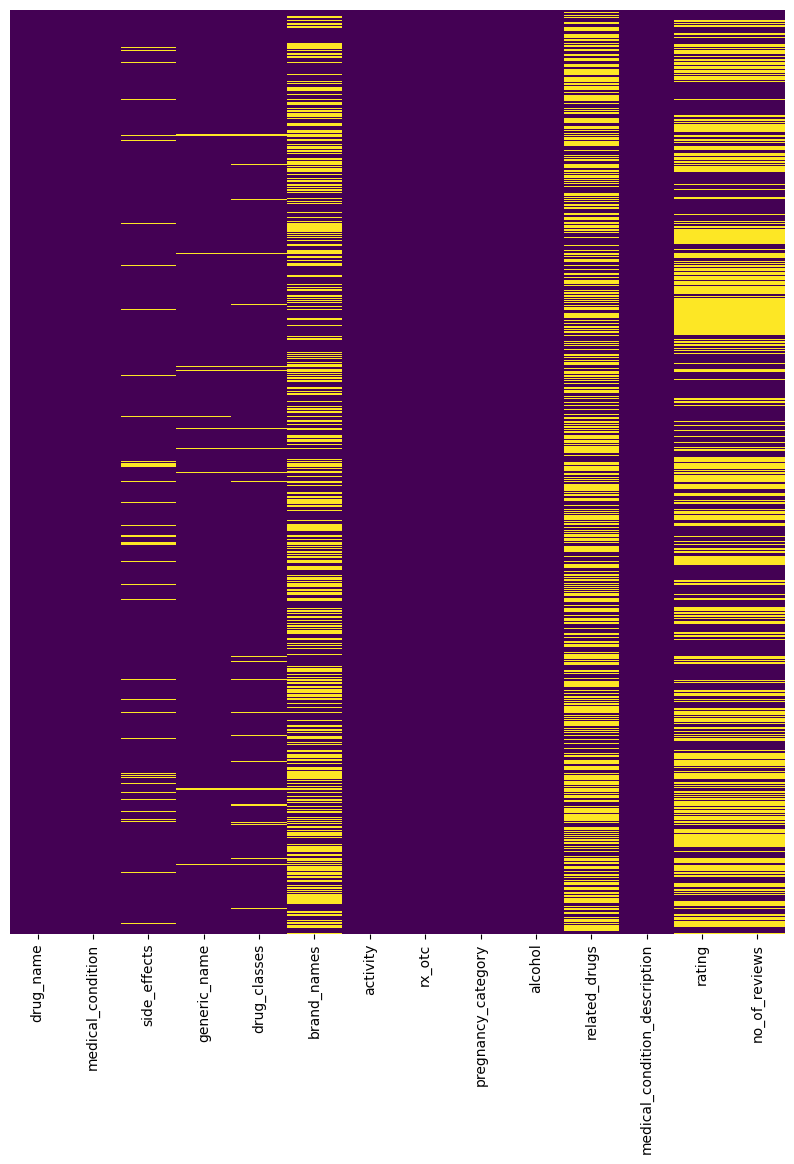

In [35]:
df =data
df.info()
# calculate duplicates
dups = df.duplicated()
# report if there are any duplicates
print(df.any())
# list all duplicate rows

print("Duplicate Rows",df[dups])
#Cardinality 
df.nunique() # To determine the maximum and minimum number of variations in each column of the dataset
#Lets now check for null fields
import seaborn as sns
plt.figure(figsize=(10,12))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
df.isnull().sum()

**Observations**:
- It can be noticed here that the missing values are being marked as Nan and this needs to be removed


# Descriptive Analytics

In [36]:
# Group data accordingly
unique_medical_conditions = list(data.medical_condition.unique())
unique_drugs = list(data.drug_name.unique())

print(f"List of unique Medical Conditions being discussed are:\n{unique_medical_conditions}\n\n")
print(f"List of unique drugs being discussed are:\n{unique_drugs}\n\n")

print(f"Number of unique drugs: {len(unique_drugs)}")
print(f"Total data rows: {data.shape[0]}")

List of unique Medical Conditions being discussed are:
['Acne', 'ADHD', 'AIDS/HIV', 'Allergies', "Alzheimer's", 'Angina', 'Anxiety', 'Asthma', 'Bipolar Disorder', 'Bronchitis', 'Cancer', 'Cholesterol', 'Colds & Flu', 'Constipation', 'COPD', 'Covid 19', 'Depression', 'Diabetes (Type 1)', 'Diabetes (Type 2)', 'Diarrhea', 'Eczema', 'Erectile Dysfunction', 'Gastrointestinal', 'GERD (Heartburn)', 'Gout', 'Hair Loss', 'Hayfever', 'Herpes', 'Hypertension', 'Hypothyroidism', 'IBD (Bowel)', 'Incontinence', 'Insomnia', 'Menopause', 'Migraine', 'Osteoarthritis', 'Osteoporosis', 'Pain', 'Pneumonia', 'Psoriasis', 'Rheumatoid Arthritis', 'Schizophrenia', 'Seizures', 'Stroke', 'Swine Flu', 'UTI', 'Weight Loss']


List of unique drugs being discussed are:
['doxycycline', 'spironolactone', 'minocycline', 'Accutane', 'clindamycin', 'Aldactone', 'tretinoin', 'isotretinoin', 'Bactrim', 'Retin-A', 'Aczone', 'benzoyl peroxide', 'Differin', 'Epiduo', 'adapalene', 'cephalexin', 'Doryx', 'tetracycline', 'Septr

**Observation**:
- Number of unique drugs and total number of data_rows are almost same, meaning that histograms for drugs won't be of any use here as there are not many repititions
- Histograms are suggested to be used when there are many data repetitions involved and there is imortance to the 'count' of a property
- But they can be used for other attributes

In [37]:
# Drugs being used for multiple medical conditions
drugs_multiple_condns = []
drugs_so_far = []

for i in data.index:
    if data["drug_name"][i] in drugs_so_far and data["drug_name"][i] not in drugs_multiple_condns:
        drugs_multiple_condns.append(data["drug_name"][i])
    if data["drug_name"][i] not in drugs_so_far:
        drugs_so_far.append(data["drug_name"][i])

print("The below is the list of only drugs that have multi-purpose:")
for i in drugs_multiple_condns:
    print(i)

The below is the list of only drugs that have multi-purpose:
minocycline
erythromycin
triamcinolone
fluocinolone
doxepin
fluticasone
mometasone
beclomethasone
ciclesonide
acyclovir
minoxidil
budesonide
hydrocortisone
cromolyn
diclofenac
diphenhydramine
clindamycin
betamethasone


# Bar Graphs



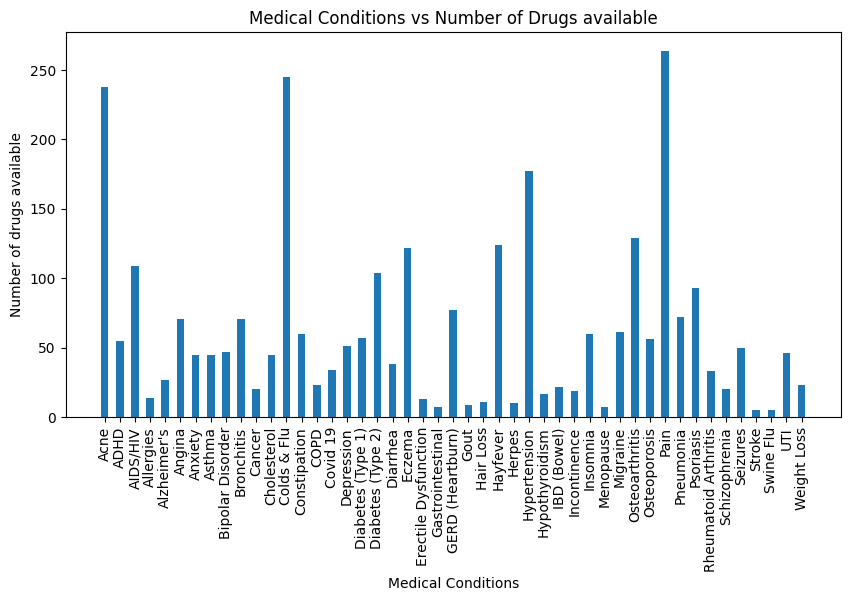

In [38]:
available_drugs_for_condns = [0]*len(unique_medical_conditions)

for i in data.index:
    medical_condition = str(data['medical_condition'][i])
    indexx = unique_medical_conditions.index(medical_condition)
    available_drugs_for_condns[indexx] += 1

#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(unique_medical_conditions, available_drugs_for_condns, width = 0.5)
plt.xlabel("Medical Conditions")
plt.ylabel(f"Number of drugs available")
plt.title(f"Medical Conditions vs Number of Drugs available")
plt.xticks(rotation=90)
plt.show()


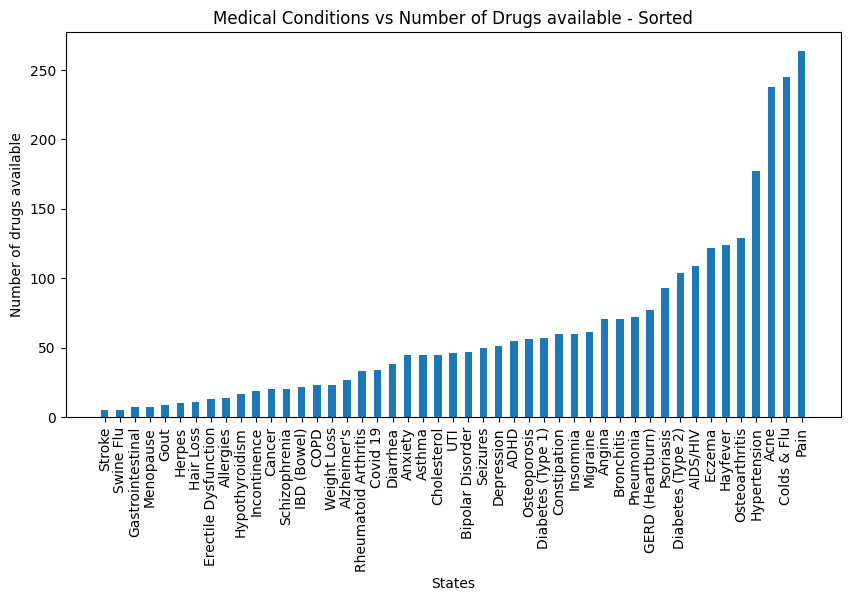

In [39]:
# Pareto Chart
available_drugs_for_condns, unique_medical_conditions = zip(*sorted(zip(available_drugs_for_condns, unique_medical_conditions)))

#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(unique_medical_conditions, available_drugs_for_condns, width = 0.5)
plt.xlabel("States")
plt.ylabel(f"Number of drugs available")
plt.title(f"Medical Conditions vs Number of Drugs available - Sorted")
plt.xticks(rotation=90)
plt.show()


**Observations**
- Most drugs are available to aid for pain, colds&flu, hypertension, osteoarthritis and Hayfever
- Least number of drugs are available for strokes, swine flu, gastrointestinal problems, menopause and gout


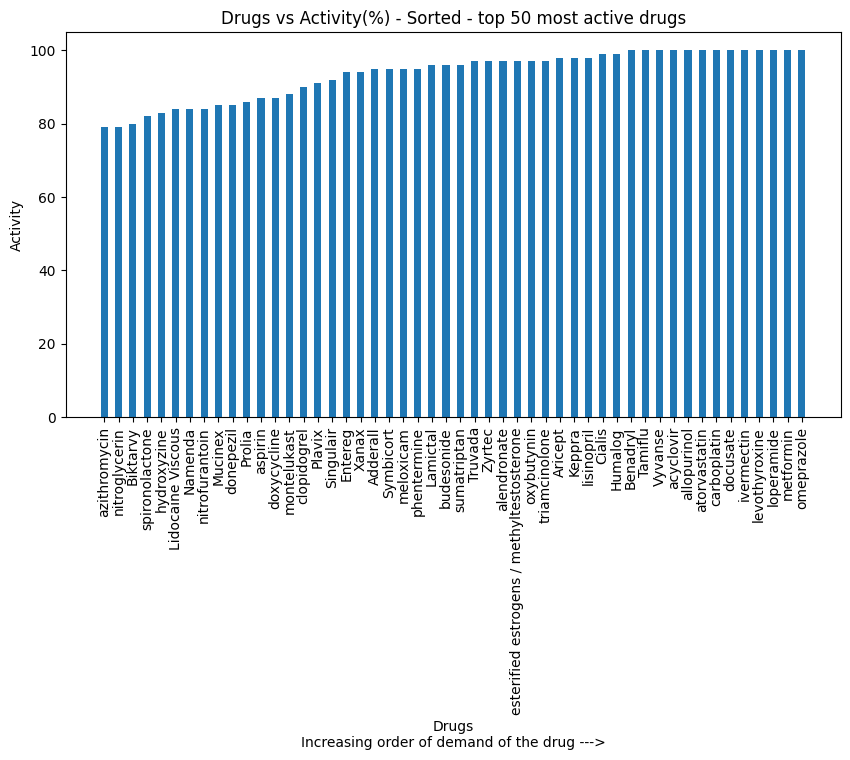

In [40]:
# print(int(data["activity"][555][:-1]))
# Drugs vs Activity
activities = []
drugs = []
for i in data.index:
    activities.append(int(data["activity"][i][:-1]))
    drugs.append(str(data["drug_name"][i]))


# Pareto Chart
activities, drugs = zip(*sorted(zip(activities, drugs)))

#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(drugs[-50:], activities[-50:], width = 0.5)
plt.xlabel("Drugs\nIncreasing order of demand of the drug --->")
plt.ylabel(f"Activity")
plt.title(f"Drugs vs Activity(%) - Sorted - top 50 most active drugs")
plt.xticks(rotation=90)
plt.show()


**Observations**:
- Omeprazole, metformin, loperamide, etc in order of decreasing priority are the most active drugs, i.e, they are in most demand from the consumer side
- It can be noticed that the top 10 in-demand drugs are of same importance in the consumer market


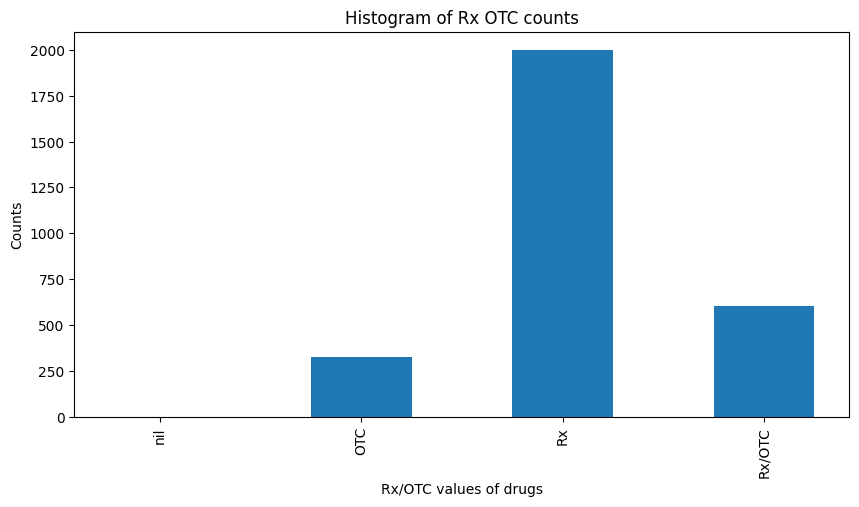

In [41]:
unique_rx_otc = ['nil', 'OTC', 'Rx', 'Rx/OTC']

cnts_rtx_otc = [0]*len(unique_rx_otc)
for i in data.index:
    if data["rx_otc"][i] == None:
        cnts_rtx_otc[0] += 1
    elif data["rx_otc"][i] == 'OTC':
        cnts_rtx_otc[1] += 1
    elif data["rx_otc"][i] == 'Rx':
        cnts_rtx_otc[2] += 1
    elif data["rx_otc"][i] == 'Rx/OTC':
        cnts_rtx_otc[3] += 1
        
# Pareto Chart
# cnts, unique_rx_otc = zip(*sorted(zip(cnts, unique_rx_otc)))

#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(unique_rx_otc, cnts_rtx_otc, width = 0.5)
plt.xlabel("Rx/OTC values of drugs")
plt.ylabel(f"Counts")
plt.title(f"Histogram of Rx OTC counts")
plt.xticks(rotation=90)
plt.show()

**Observations**:
- Most of the drugs have Rx, i.e, most of the drugs require prescription to be used. (Around 1900 from the available 2900+ drugs)
- The remaining 1000 drugs are not that dangerous and can be prescribed or not prescribed.
pre

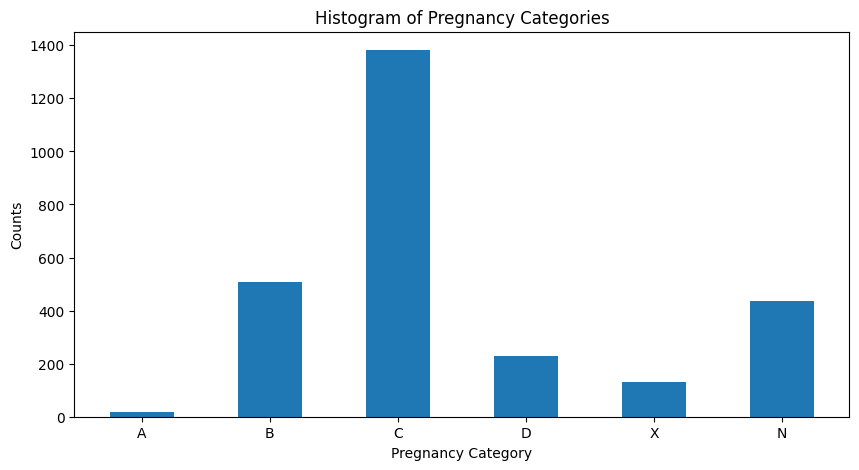

In [42]:
pregnancy_categories = ['A', 'B', 'C', 'D', 'X', 'N']

cnts_preg_cat = [0]*len(pregnancy_categories)
for i in data.index:
    if data["pregnancy_category"][i] == 'A':
        cnts_preg_cat[0] += 1
    elif data["pregnancy_category"][i] == 'B':
        cnts_preg_cat[1] += 1
    elif data["pregnancy_category"][i] == 'C':
        cnts_preg_cat[2] += 1
    elif data["pregnancy_category"][i] == 'D':
        cnts_preg_cat[3] += 1
    elif data["pregnancy_category"][i] == 'X':
        cnts_preg_cat[4] += 1
    elif data["pregnancy_category"][i] == 'N':
        cnts_preg_cat[5] += 1
    
        
# Pareto Chart
#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(pregnancy_categories, cnts_preg_cat, width = 0.5)
plt.xlabel("Pregnancy Category")
plt.ylabel(f"Counts")
plt.title(f"Histogram of Pregnancy Categories")
plt.xticks(rotation=0)
plt.show()


**Observation**:
- Most drugs come under the pregnancy category 'C', meaning that most of the drugs show an adverse effect on the fetus and there are no adequate and well-controlled studies in humans, but potential benefits may warrant use in pregnant women despite potential risks.
- Some chunk of drugs come under categories 'B', meaning that they have no effect on the fetus
- About 500 drugs are not classified by NDA


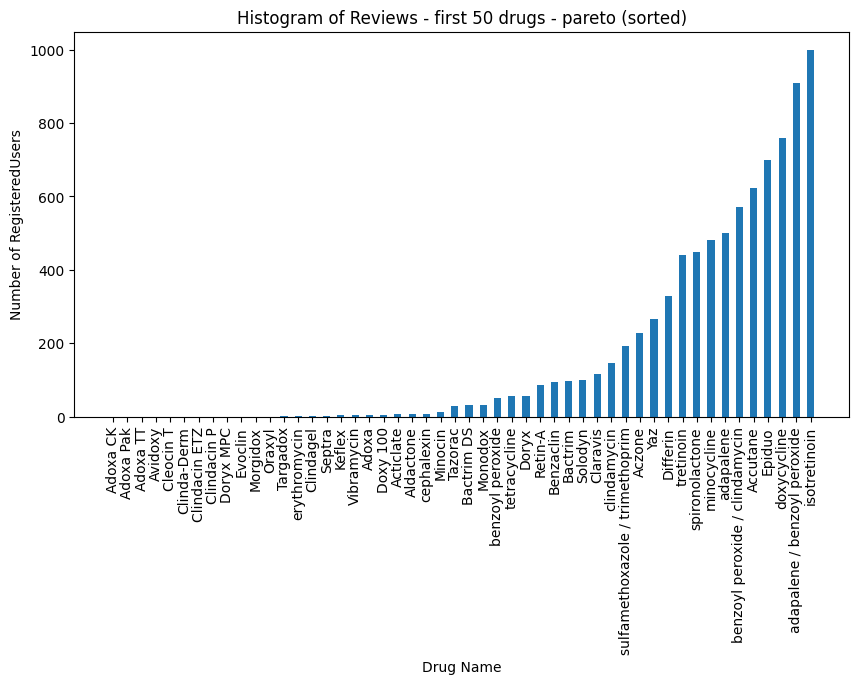

In [43]:
drug_names = []
no_of_ratings = []

num = 50

cnt = 0
for i in data.index:
    if cnt != num:
        drug_names.append(data["drug_name"][i])
        if not np.isnan(data["no_of_reviews"][i]):
            no_of_ratings.append(int(data["no_of_reviews"][i]))
        else:
            no_of_ratings.append(0)
    else:
        break
    cnt += 1

#Bar Graph
fig = plt.figure(figsize = (10, 5))
no_of_ratings, drug_names = zip(*sorted(zip(no_of_ratings, drug_names)))
# creating the bar plot
# num = 10
plt.bar(drug_names, no_of_ratings, width = 0.5)
plt.xlabel("Drug Name")
plt.ylabel(f"Number of RegisteredUsers")
plt.title(f"Histogram of Reviews - first {num} drugs - pareto (sorted)")
plt.xticks(rotation=90)
plt.show()


**Observation**:
- drugs 'isotreonoin', 'adapalene', 'doxycycline', etc in sequential orders are reviewed the most by users, indicating that they are the most used drugs in the first 50 mentioned drugs


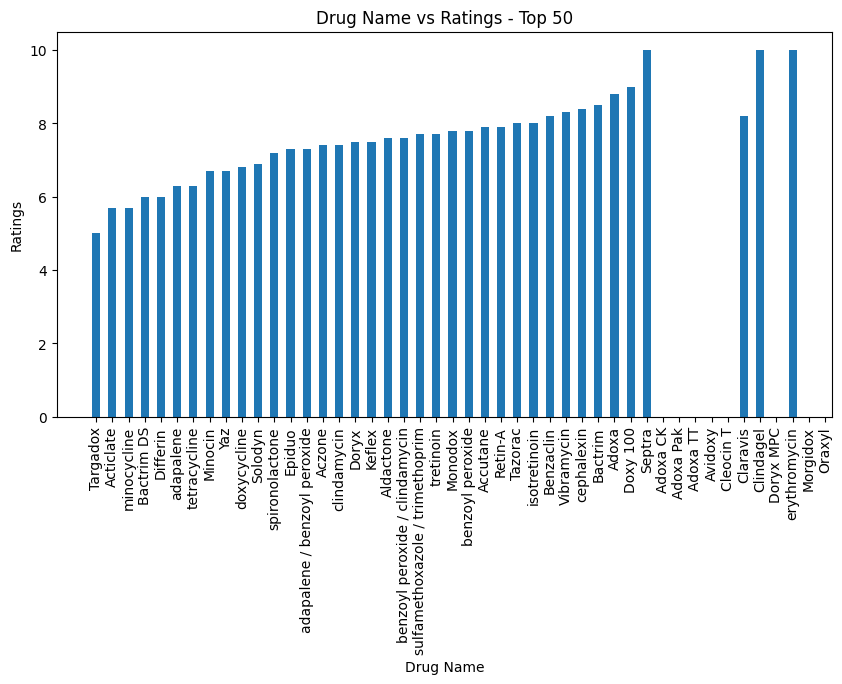

In [44]:
# Ratings
num = 50
drug_names = data["drug_name"][:num]
ratings = data["rating"][:num]
ratings, drug_names = zip(*sorted(zip(ratings, drug_names)))        
# Pareto Chart
#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(drug_names, ratings, width = 0.5)
plt.xlabel("Drug Name")
plt.ylabel(f"Ratings")
plt.title(f"Drug Name vs Ratings - Top {num}")
plt.xticks(rotation=90)
plt.show()


C:\Users\HOME\AppData\Local\Temp\ipykernel_4788\3686979007.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='rating', ylabel='count'>

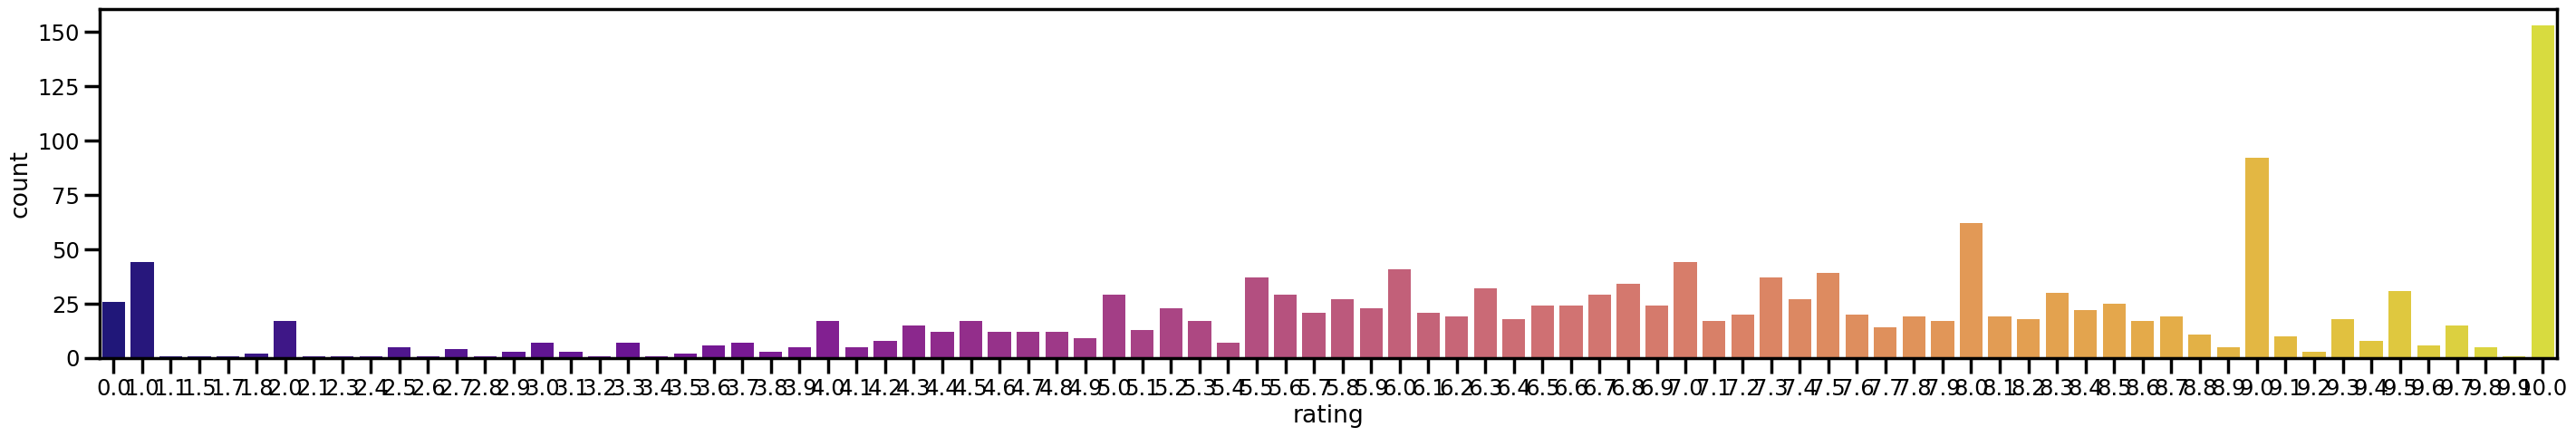

In [45]:
# Examining the variable's goal rating
sns.set_context('poster', font_scale=0.8)
plt.figure(figsize=(35,5))
sns.countplot(data=data,x = 'rating',palette='plasma')

**Observations**
- erythromycin, clindagel, septra, etc are the top rated drugs in the first 50 drugs
- It can be noticed from this that the drugs with the most number of reviews are not in the top rated drugs, i.e, number of reviews is not an apt parameter to judge the usefulness of a drug

Average number of times that medical conditions were noticed

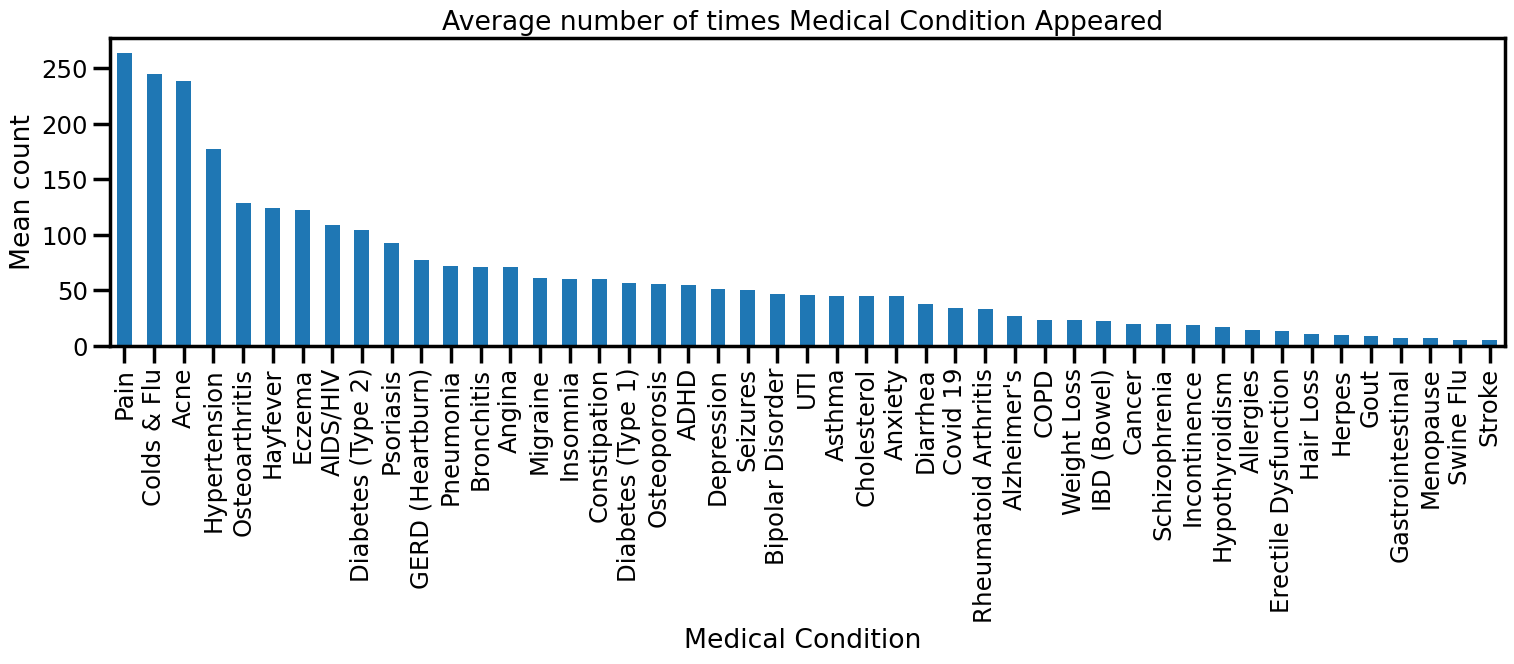

In [46]:
# data visualisation on medical_condition apears
sns.set_context('poster', font_scale=0.8)
data['medical_condition'].value_counts().plot(kind='bar', figsize=(18, 4)) 
plt.xlabel('Medical Condition ')
plt.ylabel('Mean count')
plt.title('Average number of times Medical Condition Appeared ')
plt.show()

Text(0.5, 1.0, 'Frequency of Each Medical Condition')

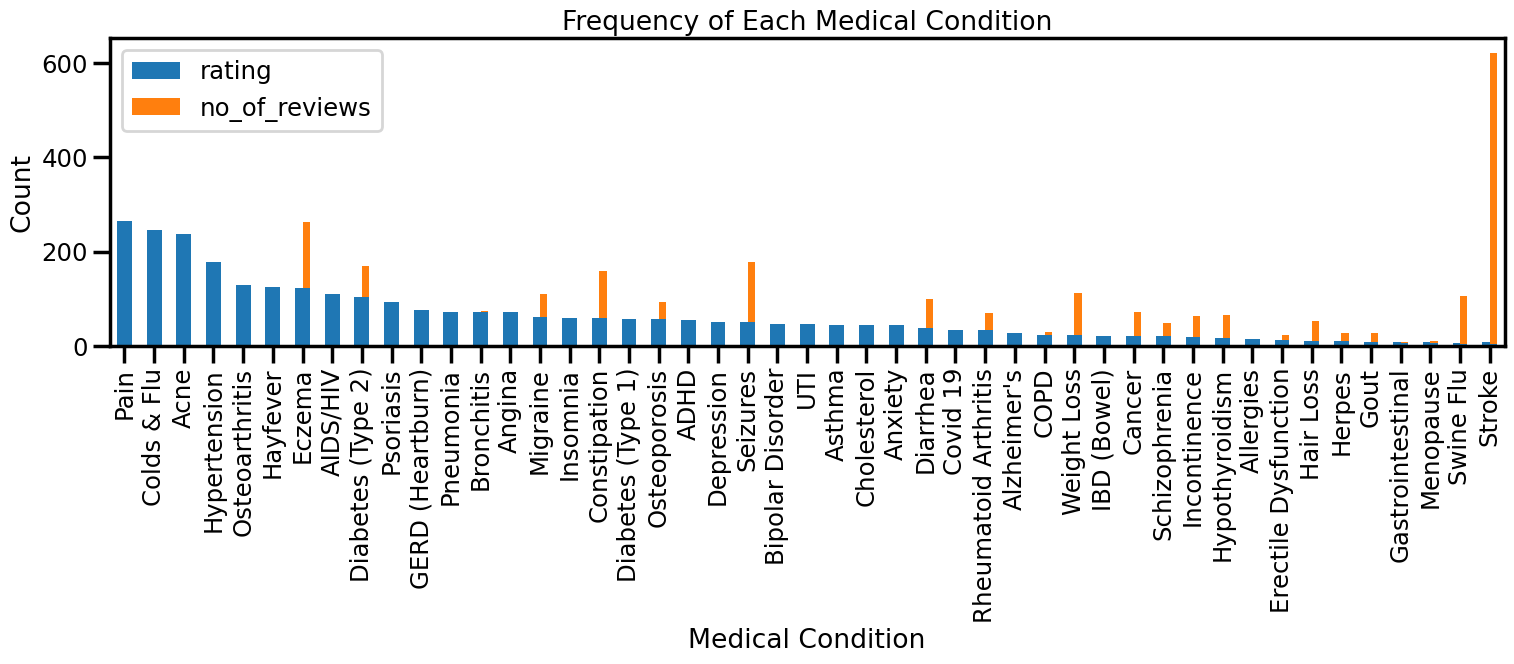

In [47]:
# This will drop any non-numeric columns like strings
data_numeric = data.select_dtypes(include='number')

# Then do groupby only on numeric part
data.groupby('medical_condition')[data_numeric.columns].mean().plot(kind='bar', figsize=(18, 4))
data['medical_condition'].value_counts().plot(kind='bar', figsize=(18, 4))
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Frequency of Each Medical Condition')


**Observations**:
- It can be noticed that weight loss drugs have most number of reviews, showing that it is a popular concern among drug-consumers
- ADHD, Anxiety, Bipolar Disorder, Depression, Erectile Disfunction are the next most used drugs

Pie Chart

1)We can use Pie Charts only for a limited combinations as it is feasible to use pie charts only when the number of attributes are lesser


2)Some possibilities are:
- Rx/OTC Distributions
- Percentage of drugs reactions with alcohol

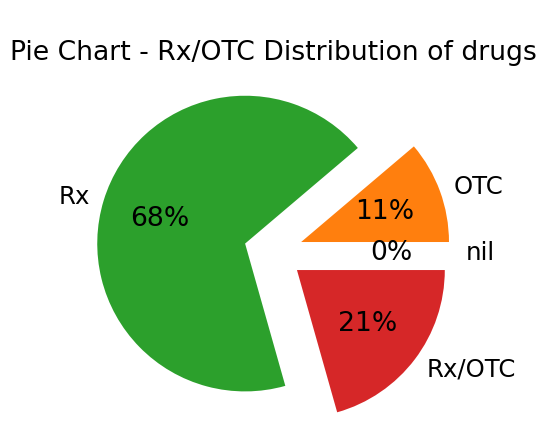

In [48]:
# Rx/OTC distributions
y = np.array(cnts_rtx_otc)
mylabels = unique_rx_otc
myexplode = [0.2]*len(unique_rx_otc)
plt.title("\nPie Chart - Rx/OTC Distribution of drugs")
plt.pie(y, labels = mylabels, explode = myexplode, autopct='%.0f%%')
plt.show() 

**Observations**
- It can be observed that 68% of the drugs are of type 'Rx', meaning that they can only be used if prescribed by a doctor
- 21% of the drugs can either be prescribed or not prescribed by a doctor
- 11% of the drugs need not be prescribed by a doctor


Target distribution on pregnancy_category column

pregnancy_category
C    1382
B     509
N     436
0     229
D     228
X     129
A      18
Name: count, dtype: int64

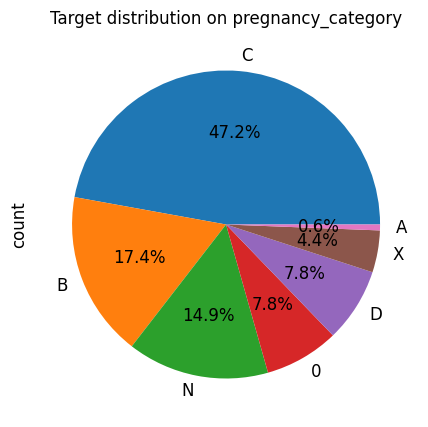

In [49]:
# Figure size 
sns.set_context('poster', font_scale=0.5)
plt.figure(figsize=(5,5))
# Pie plot
data['pregnancy_category'].value_counts().plot.pie(autopct='%1.1f%%', textprops={'fontsize':12}).set_title("Target distribution on pregnancy_category")
data['pregnancy_category'].value_counts()

**Observations**:
- Just like the bar graph, it is clear that most drugs are of pregnancy_category type C, meaning that Animal reproduction studies have shown an adverse effect on the fetus and there are no adequate and well-controlled studies in humans, but potential benefits may warrant use in pregnant women despite potential risks.


medical_condition
Pain                    264
Colds & Flu             245
Acne                    238
Hypertension            177
Osteoarthritis          129
Hayfever                124
Eczema                  122
AIDS/HIV                109
Diabetes (Type 2)       104
Psoriasis                93
GERD (Heartburn)         77
Pneumonia                72
Bronchitis               71
Angina                   71
Migraine                 61
Insomnia                 60
Constipation             60
Diabetes (Type 1)        57
Osteoporosis             56
ADHD                     55
Depression               51
Seizures                 50
Bipolar Disorder         47
UTI                      46
Asthma                   45
Cholesterol              45
Anxiety                  45
Diarrhea                 38
Covid 19                 34
Rheumatoid Arthritis     33
Alzheimer's              27
COPD                     23
Weight Loss              23
IBD (Bowel)              22
Cancer                   20
Sc

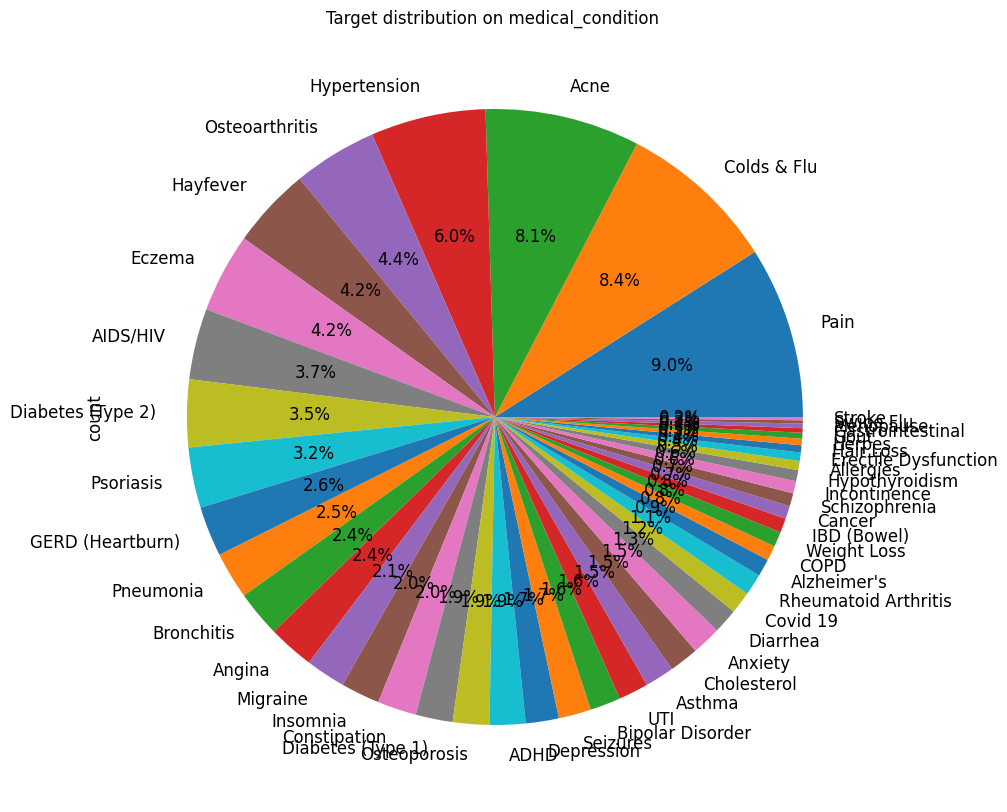

In [50]:
# Figure size 
sns.set_context('poster', font_scale=0.5)
plt.figure(figsize=(10,10))
# Pie plot
data['medical_condition'].value_counts().plot.pie(autopct='%1.1f%%', textprops={'fontsize':12}).set_title("Target distribution on medical_condition ")
data['medical_condition'].value_counts()

**Observations**:
- Top 10 diseases with most medicines available

- Pain 264
- Colds & Flu 245
- Acne 238
- Hypertension 177
- Osteoarthritis 129
- Hayfever 124
- Eczema 122
- AIDS/HIV 109
- Diabetes (Type 2) 104
- Psoriasis 93

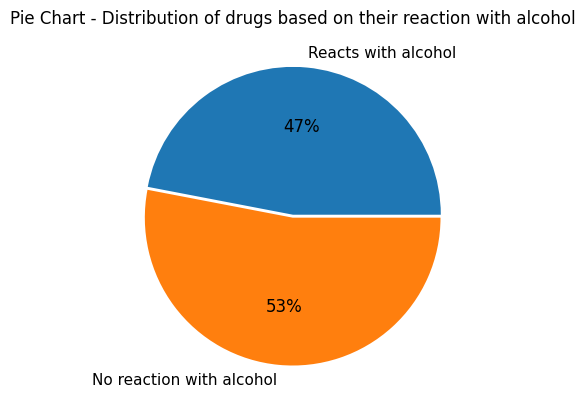

In [51]:
# Alcohol
cnts = 0

for i in data.index:
    if data["alcohol"][i] == 'X':
        cnts += 1
cnts_alcohol = [cnts, data.shape[0] - cnts]
mylabels = ["Reacts with alcohol", "No reaction with alcohol"]

# Alcohol
y = np.array(cnts_alcohol)
# mylabels = unique_rx_otc
myexplode = [0.01]*2
plt.title("Pie Chart - Distribution of drugs based on their reaction with alcohol")
plt.pie(y, labels = mylabels, explode = myexplode, autopct='%.0f%%')
plt.show() 

**Observations**:
- About 47% of the drugs have a reaction with alcohol, implying that alcoholic patients should have alternatives incase they have problems that can be solved only with these drugs

Line & Scatter Plots

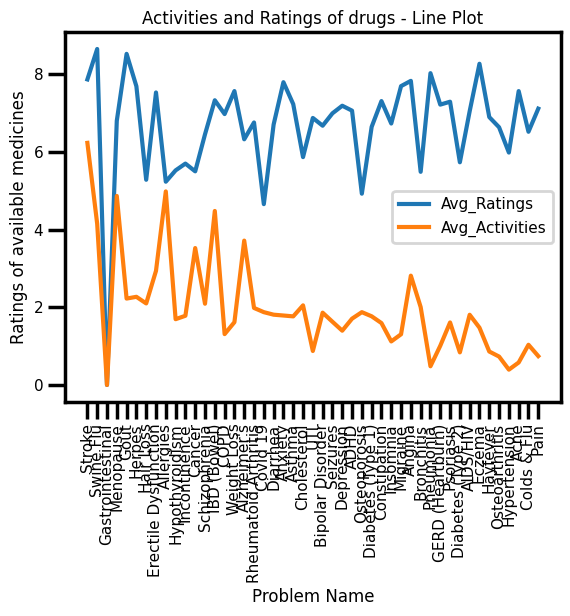

In [52]:
# Medical Conditions vs Ratings

avg_ratings = [0]*len(unique_medical_conditions)
avg_denominator = [0]*len(unique_medical_conditions)
avg_activities = [0]*len(unique_medical_conditions)
for i in range(len(unique_medical_conditions)):
    for j in data.index:
        if str(data["medical_condition"][j]) == unique_medical_conditions[i] and not np.isnan(data["rating"][j]):
            avg_ratings[i] += float(data["rating"][j])
            avg_denominator[i] += 1
            avg_activities[i] += float(data["activity"][j][:-1])

for i in range(len(unique_medical_conditions)):
    if avg_denominator[i] != 0:
        avg_ratings[i] = avg_ratings[i]/avg_denominator[i]
        avg_activities[i] = (avg_activities[i]/avg_denominator[i])/10

# for i in range(len(unique_medical_conditions)):
#     if avg_ratings[i]:
#         avg_ratings[i] = 0


plt.plot(unique_medical_conditions, np.array(avg_ratings))
plt.plot(unique_medical_conditions, np.array(avg_activities))
plt.xlabel(f"Problem Name")
plt.ylabel(f"Ratings of available medicines")
plt.title(f"Activities and Ratings of drugs - Line Plot")
plt.legend(["Avg_Ratings", "Avg_Activities"])
plt.xticks(rotation=90)
plt.show()

# Observations:
- It can clearly be noticed from here that except for a few anomalies, the ratings and activities of a drug are almost similar
- A drug with a good rating has more activity in sales and a drug with less rating has less activity in sales

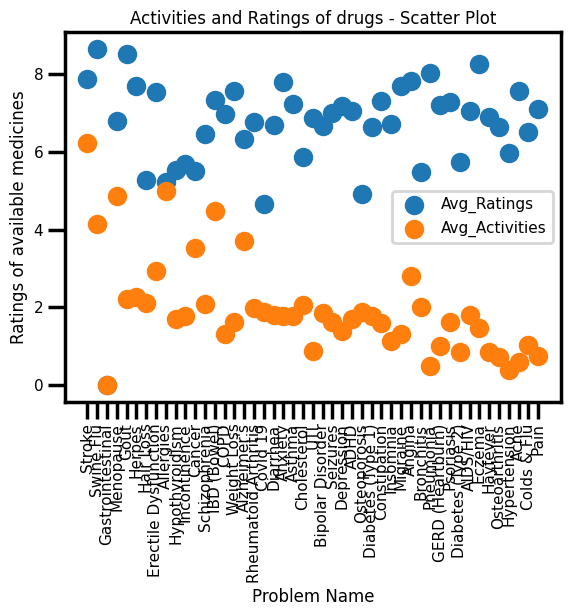

In [53]:
plt.scatter(unique_medical_conditions, np.array(avg_ratings))
plt.scatter(unique_medical_conditions, np.array(avg_activities))
plt.xlabel(f"Problem Name")
plt.ylabel(f"Ratings of available medicines")
plt.title(f"Activities and Ratings of drugs - Scatter Plot")
plt.legend(["Avg_Ratings", "Avg_Activities"])
plt.xticks(rotation=90)
plt.show()

# Observations:
- While not much can be concluded from this scatter, we can atleast say that the two parameters, ratings and activities are linearly separable

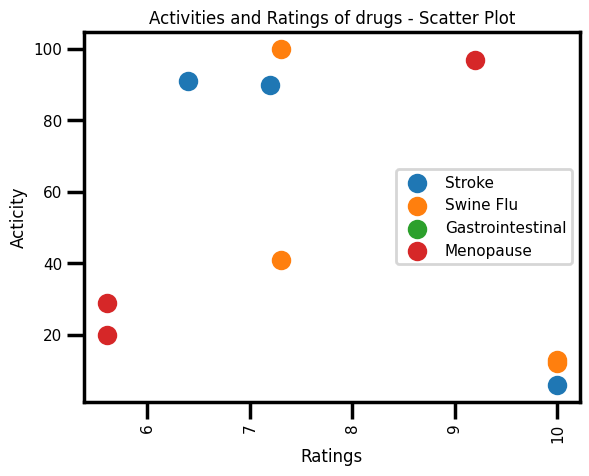

In [54]:
num = 4
diseases = unique_medical_conditions[:num]
property_chosen = [data["rating"], data["activity"]]

properties = []

for i in diseases:
    dataa = data.loc[data['medical_condition'] == i]
    rating = list(dataa["rating"])
    activity = []
    for j in dataa.index:
        activity.append(int(dataa["activity"][j][:-1]))
    plt.scatter(rating, activity)
    plt.xlabel(f"Ratings")
    plt.ylabel(f"Acticity")
    plt.title(f"Activities and Ratings of drugs - Scatter Plot")
    plt.legend(diseases)
    plt.xticks(rotation=90)

# Observations:
- It can be observed from the data that we cannot differentiate diseases based on their ratings and activity values
  

Box-Whisker Plots


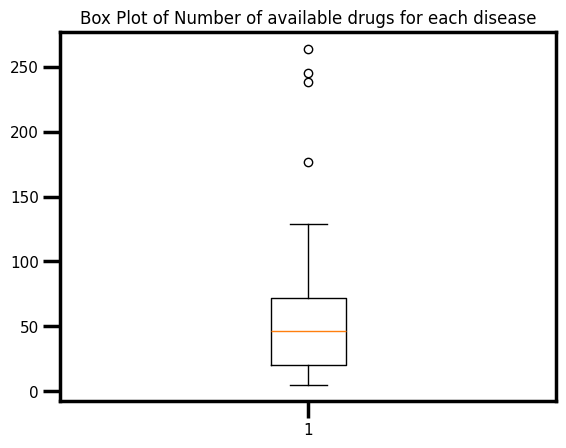

In [55]:
# available_drugs_for_condns
plt.boxplot(available_drugs_for_condns)
plt.title(f"Box Plot of Number of available drugs for each disease")
plt.show()

# Observations:
- It can be observed that this plot is not skewed as the median or 50 percentile is almost in the middle of the box.
- However, it has 4 outliers on the top meaning that there are 4 diseases who have more than abundant number of drugs available for treatment

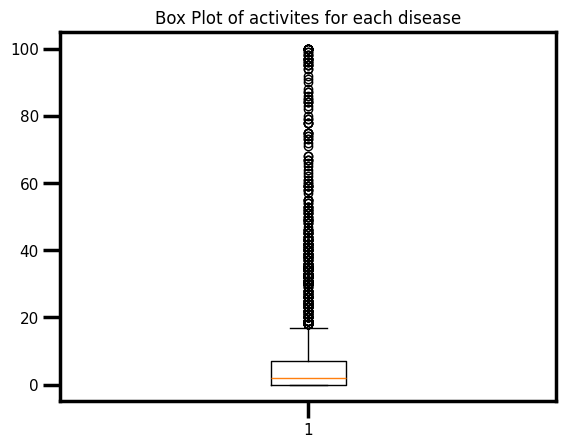

In [56]:
plt.boxplot(activities)
plt.title(f"Box Plot of activites for each disease")
plt.show()

# Observations:
- It can be observed that the given plot is right-skewed as the median/50th percentile is slightly inclined towards the bottom.
- It can also be noticed that this plot has so many outliers, stating that 'activities' parameter is not an apt attribute to use to measure the demand of a drug

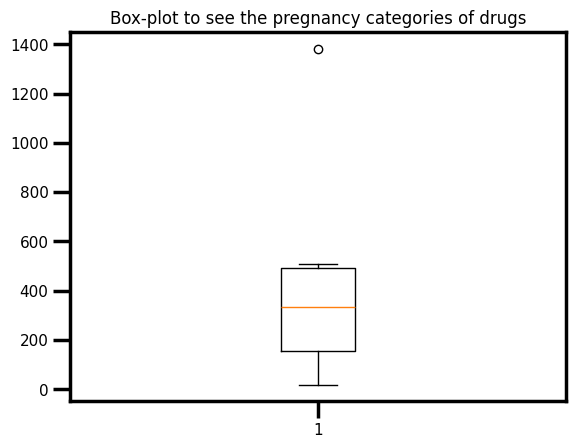

In [57]:
plt.boxplot(cnts_preg_cat)
plt.title(f"Box-plot to see the pregnancy categories of drugs")
plt.show()

# Observations:
- It can be observed that this plot of not skewed as the median or 50 percentile is almost in the middle of the box.
- However, it has no outliers on the top meaning that this can be a good attribute to be used to classify drugs

Comparing rx_oct and medical_condition


In [58]:
import plotly.express as ex
ex.box(x = 'rx_otc', y = 'medical_condition',data_frame = data, template='seaborn', notched=True, width=800, height=500)


# Observations:
- Drugs that are used for weight loss have the most need to be prescribed by Doctors only and Acne curing drugs have the least need to be prescribed by doctors



Comparing drug_classes and medical_condition

In [59]:
ex.box(x = 'medical_condition', y = 'drug_classes',data_frame = data, template='seaborn', notched=True, width=1200, height=600)


Comparing medical_condition and pregnancy_category



In [60]:
ex.box(x = 'medical_condition', y = 'pregnancy_category',data_frame = data, template='seaborn', notched=True, width=1200, height=600)


# Observations:
- ss

Violin Plots



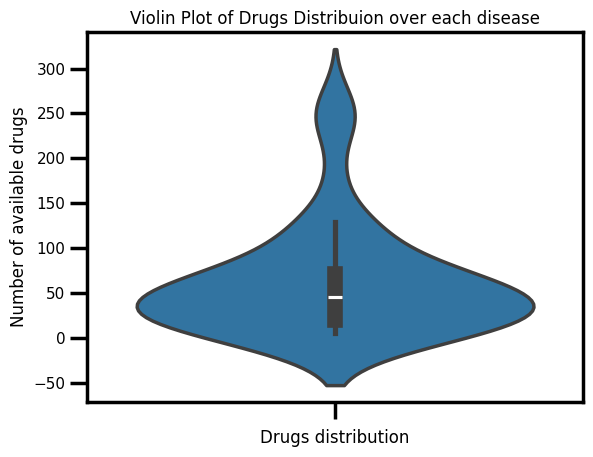

In [61]:
sns.violinplot(available_drugs_for_condns)
plt.xlabel(f"Drugs distribution")
plt.ylabel(f"Number of available drugs")
plt.title(f"Violin Plot of Drugs Distribuion over each disease")
plt.xticks(rotation=90)
plt.show()

# Observations:
- Violin plots are an improvement over box plots and they also show the density (here, magnitude) variation of the values.
- From the above violin plot, it can be seen that this plot is not skewed as the median or 50 percentile is almost in the middle of the box.
- But it has a significant number of outliers as the spread of the density is not uniform on the to (from after 150)

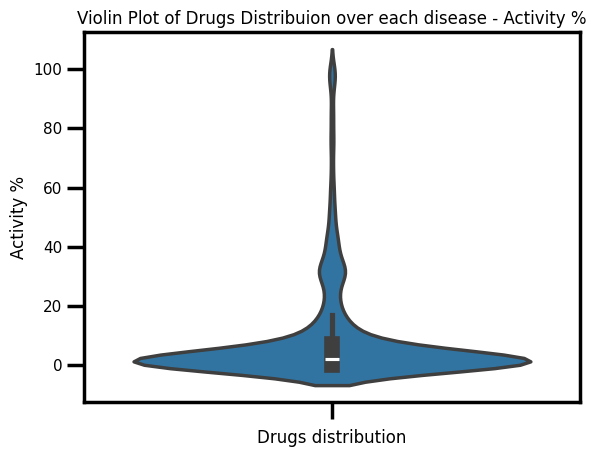

In [62]:
sns.violinplot(activities)
plt.xlabel(f"Drugs distribution")
plt.ylabel(f"Activity %")
plt.title(f"Violin Plot of Drugs Distribuion over each disease - Activity %")
plt.xticks(rotation=90)
plt.show()

# Observations:
- Violin plots are an improvement over box plots and they also show the density (here, magnitude) variation of the values.
- From the above violin plot, it can be seen that this plot is right-skewed as the median or 50 percentile is almost in the botton of the box.
- But it has a large number of outliers as the spread of the density is not at all uniform on the to (from after 20)
- The shape of the density indicated that the first few mentioned drugs have the most activity (usage from users)

Stem Leaf Plots



(<Figure size 750x300 with 1 Axes>, <Axes: >)

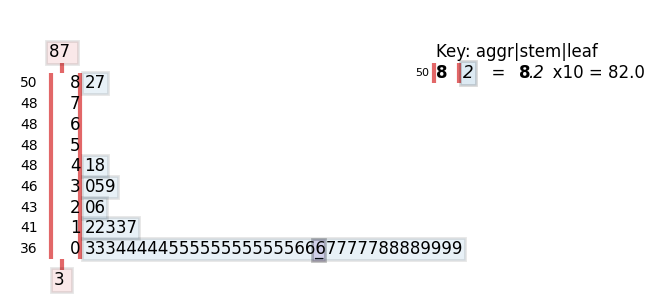

In [63]:
data = pd.read_csv("wakeel project/drugs_side_effects_drugs_com.csv")
num = 50
activity = []
for i in data.index:
    activity.append(int(data["activity"][i][:-1]))
# print(f"Number of Reviews of the first {num} drugs")
stemgraphic.stem_graphic(activity[:num] , scale = 10)


# Observations:
- Most of the drugs have their activities lying in the range 0-10 as that has the most values in the first 50 drugs
- 82, 87, 41, 48 percentages are all mostly outliers, but they cannot be ignored as their activity percent is higher, meaning that they have more demand in market

Radar Chart



In [64]:
categories = ["activity", "rating", "no_of_reviews"]

print("Radar Chart")
fig = go.Figure()
plt.Figure(figsize =(5, 3))

fig.add_trace(go.Scatterpolar(r=data.loc[data["medical_condition"] == 'Acne'], theta=categories, fill='toself', name='acne'))
fig.add_trace(go.Scatterpolar(r=data.loc[data["medical_condition"] == 'Anxiety'], theta=categories, fill='toself', name='anxiety'))
fig.add_trace(go.Scatterpolar(r=data.loc[data["medical_condition"] == 'Asthma'], theta=categories, fill='toself', name='asthma'))
fig.add_trace(go.Scatterpolar(r=data.loc[data["medical_condition"] == 'Weight Loss'], theta=categories, fill='toself', name='weight loss'))
fig.update_layout(autosize=False, width=400, height=400)

fig.show()

Radar Chart


Radar Chart


# Observations:
- It can be observed that the ratios of ratings, activites, and number of reviews of acne, anxiety, asthma and weight loss are all aligned.


Funnel Chart



In [65]:
# Data as a dictionary

arr = []
# for i in data.columns[3:]:
#     arr.append(math.ceil(statistics.mean(data1[i])))
#available_drugs_for_condns, unique_medical_conditions = zip(*sorted(zip(available_drugs_for_condns, unique_medical_conditions)))
data = dict(time=available_drugs_for_condns,
            steps=unique_medical_conditions)

fig = px.funnel(data, x='time', y='steps')
print("Funnel Chart for Diseases and Available drugs")
fig.show()

Funnel Chart for Diseases and Available drugs


Funnel Chart for Diseases and Available drugs


# Observations:
- As noted in the pareto chats, it can be seen that most drugs are available for pain, acne, osteoarithritis, etc in priority order



Heat Maps



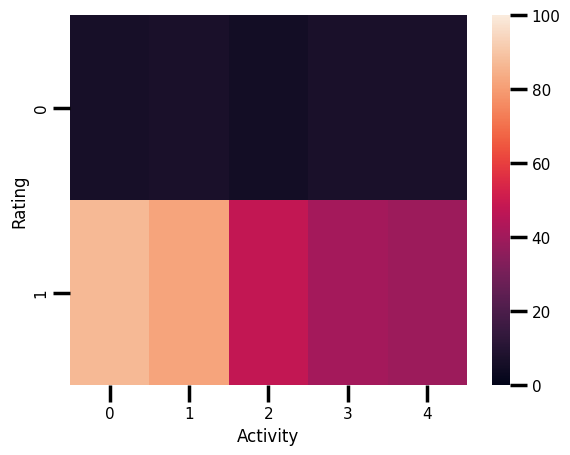

In [66]:
data = load_data()
activity = []
rating = []
for i in data.index:
    activity.append(int(data["activity"][i][:-1]))
    if not np.isnan(data["rating"][i]):
            rating.append(int(data["rating"][i]))
    else:
            rating.append(0)
num = 5
# correlation_matrix = np.corrcoef(activity[:num], rating[:num])
heatmap_sepal = sns.heatmap([rating[:num], activity[:num]], vmin = 0, vmax = 100)
plt.xlabel("Activity")
plt.ylabel("Rating")
plt.show()


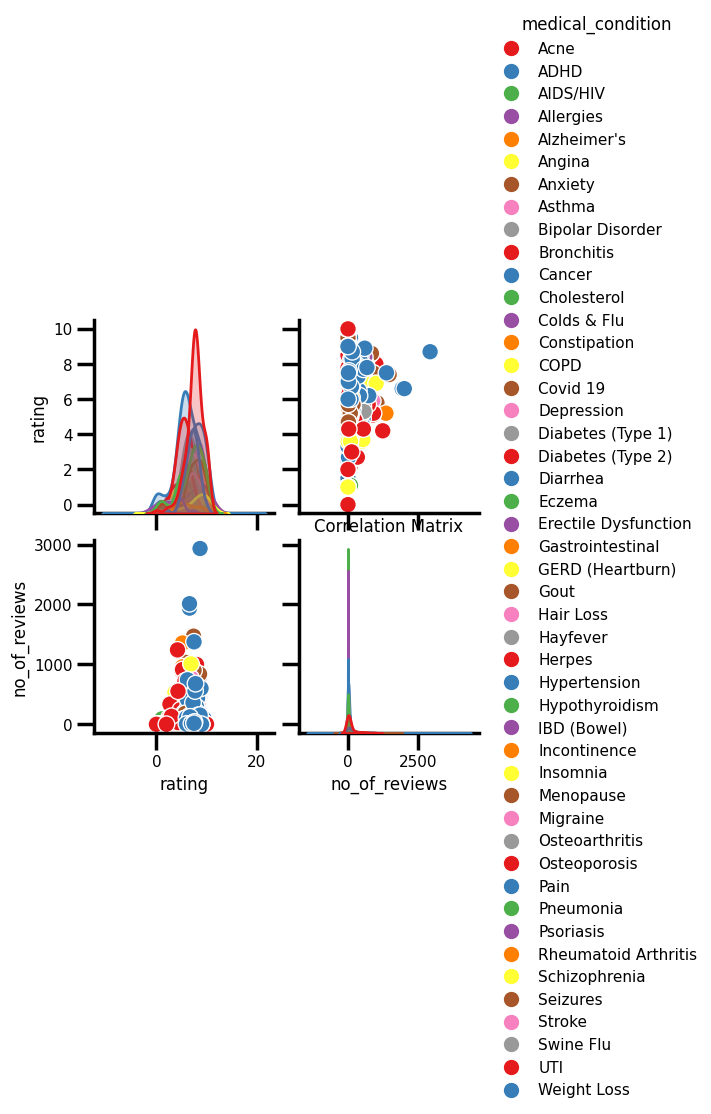

In [67]:
data = load_data()
df = data[["medical_condition", "rating", "no_of_reviews"]]
# df.drop(columns=df.columns[0], axis=1,  inplace=True)
sns.pairplot(df, kind="scatter", hue="medical_condition", palette="Set1")
plt.title("Correlation Matrix")
plt.show()


# Apriori Algorithm

To find drugs that are most related to each other, i.e, to find Frequent Patterns



In [68]:
# Transactions
cnt = 0
for i in data.index:
    related_drugs[cnt].append(data["drug_name"][i])
    cnt += 1
    
print(related_drugs)

[['amoxicillin', 'prednisone', 'albuterol', 'ciprofloxacin', 'azithromycin', 'cephalexin', 'metronidazole', 'metronidazole topical', 'clindamycin topical', 'clindamycin', 'doxycycline'], ['amlodipine', 'lisinopril', 'losartan', 'metoprolol', 'furosemide', 'hydrochlorothiazide', 'carvedilol', 'warfarin', 'Lasix', 'bumetanide', 'spironolactone'], ['amoxicillin', 'prednisone', 'doxycycline', 'ciprofloxacin', 'azithromycin', 'cephalexin', 'metronidazole', 'clindamycin topical', 'Augmentin', 'dexamethasone', 'minocycline'], ['doxycycline', 'clindamycin topical', 'erythromycin topical', 'tetracycline', 'Tazorac', 'Accutane'], ['doxycycline', 'metronidazole', 'metronidazole topical', 'clindamycin', 'erythromycin topical', 'tetracycline', 'isotretinoin', 'tinidazole', 'Cleocin', 'MetroGel', 'clindamycin'], ['amlodipine', 'lisinopril', 'losartan', 'metoprolol', 'furosemide', 'hydrochlorothiazide', 'carvedilol', 'spironolactone', 'Lasix', 'bumetanide', 'Aldactone'], ['tretinoin'], ['doxycycline'

In [69]:
# Use the Apriori algorithm to generate frequent itemsets
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)

# Use the Association Rules algorithm to generate rules with a minimum confidence
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Print the frequent itemsets and association rules
print("Frequent Itemsets:")
print(frequent_itemsets)

print("\nAssociation Rules:")
print(rules)

ValueError: NaN values are not permitted in the DataFrame when null_values=False.

In [ ]:
# Get the length of the largest frequent itemset
max_len = frequent_itemsets["itemsets"].apply(lambda x: len(x)).max()

# Print only the last level of frequent itemsets
print("Frequent Itemsets (Level {}):".format(max_len))
last_level_itemsets = frequent_itemsets[frequent_itemsets["itemsets"].apply(lambda x: len(x))==max_len]
print(last_level_itemsets)

# Use the Association Rules algorithm to generate rules with a minimum confidence
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Print the association rules for the last level frequent itemsets
print("\nAssociation Rules for Frequent Itemsets (Level {}):".format(max_len))
last_level_rules = rules[rules["antecedents"].apply(lambda x: len(x)==max_len)]
print(last_level_rules)


# FP Growth Algorithm

To find drugs that are most related to each other, i.e, to find Frequent Patterns



In [ ]:
#traversal through database for once took 4 mins
import numpy as np
# Gather All Items of Each Transactions into Numpy Array
from itertools import chain
transaction = list(chain.from_iterable(related_drugs))
# converting to numpy array
transaction = np.array(transaction)
print(transaction)


In [ ]:
#  Transform Them a Pandas DataFrame
df = pd.DataFrame(transaction, columns=["items"]) 
# Put 1 to Each Item For Making Countable Table, to be able to perform Group By
df["incident_count"] = 1 
#  Delete NaN Items from Dataset
indexNames = df[df['items'] == "nan" ].index
df.drop(indexNames , inplace=True)
# Making a New Appropriate Pandas DataFrame for Visualizations  
df_table = df.groupby("items").sum().sort_values("incident_count", ascending=False).reset_index()
#  Initial Visualizations
df_table.head(5).style.background_gradient(cmap='Blues')

In [ ]:
# to have a same origin
df_table["all"] = "Top 50 items" 
# creating tree map using plotly
fig = px.treemap(df_table.head(50), path=['all', "items"], values='incident_count',
                  color=df_table["incident_count"].head(50), hover_data=['items'],
                  color_continuous_scale='Blues',
                )
# ploting the treemap
fig.show()


In [ ]:
te = TransactionEncoder()
te_ary = te.fit_transform(related_drugs)

# Print the one-hot encoded Boolean array
print(te_ary)
dataset = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
# select top 30 items
first30 = df_table["items"].head(30).values 
# Extract Top 30
dataset = dataset.loc[:,first30] 
# shape of the dataset
dataset.shape

In [ ]:
# select top 30 items
first30 = df_table["items"].head(30).values 
# Extract Top 30
dataset = dataset.loc[:,first30] 
# shape of the dataset
dataset.shape

In [ ]:
from mlxtend.frequent_patterns.fpgrowth import fpgrowth
#running the fpgrowth algorithm
res=fpgrowth(dataset,min_support=0.05, use_colnames=True)
# printing top 10
res

In [ ]:
transactions = related_drugs
print(transactions[:10])


In [ ]:
# Generate frequent 1-itemsets
candidate_1_itemsets = []
for transaction in transactions:
    for item in transaction:
        if [item] not in candidate_1_itemsets:
            candidate_1_itemsets.append([item])
print(len(candidate_1_itemsets))                        
print(candidate_1_itemsets)            


In [ ]:
def prune(itemsets, min_support, transactions):
    frequent_itemsets = []
    for itemset in itemsets:
        support_count = 0
        for transaction in transactions:
            if set(itemset).issubset(set(transaction)):
                support_count += 1
        if support_count >= min_support:
            frequent_itemsets.append(itemset)
    return frequent_itemsets
frequent_itemsets = prune(candidate_1_itemsets, 100 , transactions)
print(len(frequent_itemsets))
print(frequent_itemsets)

In [ ]:
def generate_candidates(itemsets, k):
    candidates = []
    for itemset1 in itemsets:
        for itemset2 in itemsets:
            if itemset1 != itemset2 and len(set(itemset1) | set(itemset2)) == k:
                candidate = sorted(list(set(itemset1) | set(itemset2)))
                if candidate not in candidates:
                    candidates.append(candidate)
    return candidates

'''candidate_2_itemsets = generate_candidates(frequent_itemsets,2)
frequent_itemsets = prune(candidate_2_itemsets, 300 , transactions)
print(frequent_itemsets)
print("\n")'''

def flatten(l):
    return set([item for sublist in l for item in sublist])

k=2
while len(frequent_itemsets)>0:
    candidate_itemsets=generate_candidates(frequent_itemsets,k)
    reduced_transactions = []
    for transaction in transactions:
        reduced_transaction = [item for item in transaction if item in set(flatten(frequent_itemsets))]
        if len(reduced_transaction) > 0:
            reduced_transactions.append(reduced_transaction)
    frequent_itemsets = prune(candidate_itemsets, 100 , reduced_transactions)
    print("itemsets of length ",k)
    print(len(frequent_itemsets))
    print(frequent_itemsets)  
    print("\n")
    k+=1

# Closed Frequent Itemsets

In [ ]:
# Import the required libraries
from collections import defaultdict
import itertools

# Define a function to compute the support of each itemset
def compute_support(itemsets, transactions):
    support = defaultdict(int)
    for transaction in transactions:
        for itemset in itemsets:
            if set(itemset).issubset(transaction):
                support[frozenset(itemset)] += 1
    return support

# Define the sample dataset
min_support = 1000

# Find all frequent itemsets and their support values
frequent_itemsets = {}
itemsets = set(item for transaction in transactions for item in transaction)
for k in range(1, len(itemsets)+1):
    candidate_itemsets = [set(itemset) for itemset in itertools.combinations(itemsets, k)]
    support = compute_support(candidate_itemsets, transactions)
    for itemset in support:
        if support[itemset] >= min_support:
            frequent_itemsets[frozenset(itemset)] = support[itemset]

# Initialize the closed frequent itemsets
closed_itemsets = frequent_itemsets.copy()[:10]

# Compute the closure of each frequent itemset
for itemset1 in frequent_itemsets[:10]:
    for itemset2 in frequent_itemsets[:10]:
        if itemset1 != itemset2 and itemset1.issubset(itemset2) and frequent_itemsets[itemset1] == frequent_itemsets[itemset2]:
            closed_itemsets.pop(itemset1, None)
            break

# Print the resulting closed frequent itemsets
print(closed_itemsets)

# min_support = 1000

# # Find all frequent itemsets and their support values
# frequent_itemsets = {}
# itemsets = set(item for transaction in transactions for item in transaction)
# for k in range(1, len(itemsets)+1):
#     candidate_itemsets = [set(itemset) for itemset in itertools.combinations(itemsets, k)]
#     support = compute_support(candidate_itemsets, transactions)
#     for itemset in support:
#         if support[itemset] >= min_support:
#             frequent_itemsets[frozenset(itemset)] = support[itemset]

# # Initialize the closed frequent itemsets
# closed_itemsets = frequent_itemsets.copy()

# # Compute the closure of each frequent itemset
# for itemset1 in frequent_itemsets:
#     for itemset2 in frequent_itemsets:
#         if itemset1 != itemset2 and itemset1.issubset(itemset2) and frequent_itemsets[itemset1] == frequent_itemsets[itemset2]:
#             closed_itemsets.pop(itemset1, None)
#             break

# # Print the resulting closed frequent itemsets
# print(closed_itemsets)

# Decision Tree


In [ ]:
data = pd.read_csv("wakeel project/drugs_side_effects_drugs_com.csv")

data = data.replace('nan', np.nan)
data = data.dropna()

In [ ]:
data.alcohol.unique()


In [ ]:
array(['X'], dtype=object)


In [ ]:
data.pregnancy_category.unique()


In [ ]:
array(['D', 'C', 'X', 'B', 'N'], dtype=object)


In [ ]:
# create a dictionary to map the values
pregnancy_map = {'X': 0, 'B': 1, 'C': 2, 'D': 3, 'N' : 0}

# map the values in the 'pregnancy' column using the dictionary
data['pregnancy_category'] = data['pregnancy_category'].map(pregnancy_map)
            
data

In [ ]:
data.rx_otc.unique()

In [ ]:
# create a dictionary to map the values
rx_map = {'Rx': 0, 'OTC': 1, 'Rx/OTC': 2}

# map the values in the 'pregnancy' column using the dictionary
data['rx_otc'] = data['rx_otc'].map(rx_map)
            
data


In [ ]:
data.activity.unique()



In [ ]:
data['activity'] = data['activity'].str.strip('%')
data.activity.unique()

In [ ]:
data['activity'] = data['activity'].astype(float)
data.activity.unique()

In [ ]:
data


In [ ]:
data.pregnancy_category.unique()

In [ ]:
df=data
# convert each column to a numeric data type
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# drop columns with non-numeric values
df_clean = df_numeric.dropna(axis=1)

# display the updated DataFrame
print(df_clean)

In [ ]:
### import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

df=df_clean
# split the data into input and output variables
X = df.drop('rx_otc', axis=1)
y = df['rx_otc']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# create a decision tree classifier with default parameters
dtc = DecisionTreeClassifier()

# train the model on the training data
dtc.fit(X_train, y_train)

# evaluate the model on the testing data
score = dtc.score(X_test, y_test)

print(f"Decision Tree Accuracy: {score:.3f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# perform k-means clustering with k=3
df=df_clean
df=data[['rating', 'activity']]
df = df.dropna()

X = df.values
X = df.values
kmeans = KMeans(n_clusters=3)
y_kmeans = kmeans.fit_predict(X)

# visualize the clusters with a scatter plot
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('K-Means Clustering')
plt.xlabel('rating')
plt.ylabel('activity')
plt.legend()
plt.show()

# Observations:
- it can be observed that 'activity' and 'rating' can be used as parameters to form clusters and differentiate between drugs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# perform k-means clustering with k=3
df=df_clean
df=data[['no_of_reviews', 'activity']]
df = df.dropna()

X = df.values
X = df.values
kmeans = KMeans(n_clusters=3)
y_kmeans = kmeans.fit_predict(X)

# visualize the clusters with a scatter plot
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('K-Means Clustering')
plt.xlabel('no_of_reviews')
plt.ylabel('activity')
plt.legend()
plt.show()